# Diagonal error grouping (`diag_error_structure`)

This notebook demonstrates the `diag_error_structure` option in `moogp.MOOGP`,
an LCGP-style grouping of the diagonal measurement-error covariance.

Given $p$ outputs, a grouping $[p_1, p_2, \dots, p_G]$ with $\sum p_g = p$
imposes
$$
\Sigma_\varepsilon = \mathrm{bdiag}\!\left(\sigma_1^2 I_{p_1}, \sigma_2^2 I_{p_2}, \dots, \sigma_G^2 I_{p_G}\right),
$$
so the model fits $G$ free variances instead of $p$. Outputs that share a
common scale or noise mechanism (e.g. measurements of the same physical
quantity at different sensor locations) can be grouped together to share a
single estimate.

The default (`diag_error_structure=None`) is equivalent to `[1] * p`, i.e.
one parameter per output (the previous behavior).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from moogp.model import (
    MOOGP,
    expand_grouped_sigma_eps2,
    normalize_diag_error_structure,
)

rng = np.random.default_rng(0)
plt.rcParams['figure.dpi'] = 110

## 1. Synthetic data with two noise regimes

We synthesize $p = 6$ outputs from two underlying smooth latent signals.

* Outputs **0–2** are derived from signal $s_1$ and observed with **small** noise.
* Outputs **3–5** are derived from signal $s_2$ and observed with **large** noise.

We will fit two models and compare them:

1. Default per-output noise (`diag_error_structure=None`, $G = p = 6$ free parameters).
2. Grouped noise with `diag_error_structure=[3, 3]` ($G = 2$ free parameters).

In [2]:
n, d = 80, 1
es = (3, 3)
p = sum(es)
small, large = 1e-3, 0.25
true_per_output = expand_grouped_sigma_eps2(np.array([small, large]), es)

X_phys = rng.uniform(0.0, 1.0, size=(n, 1))
X = 2.0 * X_phys - 1.0
s1 = np.sin(3.0 * X_phys.ravel())
s2 = np.cos(3.5 * X_phys.ravel())
Y_clean = np.column_stack([s1, 0.7 * s1, 1.3 * s1,
                            s2, 0.6 * s2, 1.1 * s2])
Y = Y_clean + rng.normal(0.0, np.sqrt(true_per_output), size=Y_clean.shape)
print('Y shape:', Y.shape)
print('per-output sample variance:', Y.var(axis=0, ddof=1).round(4))
print('true per-output noise variance:', true_per_output)

Y shape: (80, 6)
per-output sample variance: [0.09   0.0478 0.163  0.723  0.4174 1.1138]
true per-output noise variance: [0.001 0.001 0.001 0.25  0.25  0.25 ]


## 2. Helpers to assemble `theta0` and bounds

In [3]:
def build_theta0_and_bounds(q, d, n_sigma_groups, sigma_init=0.05):
    """Build a starting parameter vector + L-BFGS bounds."""
    theta, bounds = [], []
    # latent kernel block: log sigma2 + log ell per latent
    for _ in range(q):
        theta.append(np.log(1.0))
        theta.extend([np.log(0.5)] * d)
        bounds.append((np.log(1e-3), np.log(1e3)))
        bounds.extend([(np.log(0.05), np.log(5.0))] * d)
    # one log-variance per group
    theta.extend([np.log(sigma_init)] * n_sigma_groups)
    bounds.extend([(np.log(1e-8), np.log(10.0))] * n_sigma_groups)
    return np.asarray(theta), bounds

## 3. Fit the grouped model

In [4]:
q = 2
model_grp = MOOGP(
    terms=[None, 1],
    q=q,
    learn_sigma_eps=True,
    diag_error_structure=es,           # <-- the new option
    jitter=0.0,
)
theta0, bounds = build_theta0_and_bounds(q, d, n_sigma_groups=len(es))
model_grp.fit(
    data={'X_scaled': X, 'y': Y},
    theta0=theta0,
    bounds=bounds,
    optimizer_opts={'maxiter': 200},
)
print('Fitted theta length (grouped):', model_grp.theta_hat.size)
print('Number of free sigma params:', len(es))
print('Fitted per-group variances:',
      np.unique(model_grp.cache['sigma_eps2']).round(5))
print('Fitted per-output variances (broadcast across groups):',
      model_grp.cache['sigma_eps2'].round(5))
print('NLL:', model_grp.nll_hat)

Fitted theta length (grouped): 6
Number of free sigma params: 2
Fitted per-group variances: [0.00186 0.2454 ]
Fitted per-output variances (broadcast across groups): [0.00186 0.00186 0.00186 0.2454  0.2454  0.2454 ]
NLL: -227.30740963434351


## 4. Fit the per-output baseline for comparison

In [5]:
model_full = MOOGP(
    terms=[None, 1],
    q=q,
    learn_sigma_eps=True,
    diag_error_structure=None,        # default = [1]*p, p free parameters
    jitter=0.0,
)
theta0_full, bounds_full = build_theta0_and_bounds(q, d, n_sigma_groups=p)
model_full.fit(
    data={'X_scaled': X, 'y': Y},
    theta0=theta0_full,
    bounds=bounds_full,
    optimizer_opts={'maxiter': 200},
)
print('Fitted theta length (per-output):', model_full.theta_hat.size)
print('Fitted per-output variances:',
      model_full.cache['sigma_eps2'].round(5))
print('NLL:', model_full.nll_hat)

Fitted theta length (per-output): 10
Fitted per-output variances: [0.00177 0.00178 0.00192 0.26231 0.23762 0.23642]
NLL: -229.90174936160673


## 5. Compare the recovered noise variances

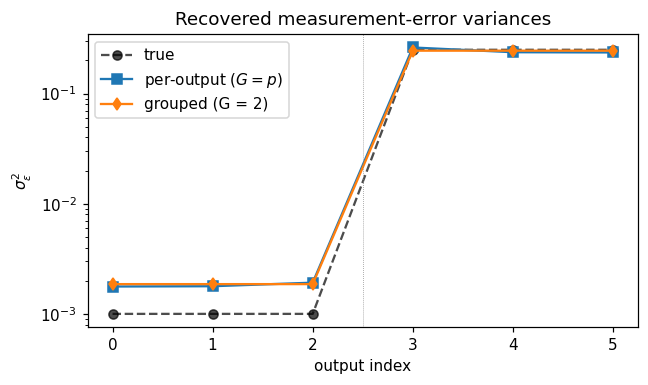

In [6]:
fig, ax = plt.subplots(figsize=(6.0, 3.6))
out = np.arange(p)
ax.plot(out, true_per_output, 'k--o', label='true', alpha=0.7)
ax.plot(out, model_full.cache['sigma_eps2'], 's-', label='per-output ($G = p$)')
ax.plot(out, model_grp.cache['sigma_eps2'], 'd-', label=f'grouped (G = {len(es)})')
for boundary in np.cumsum(es)[:-1]:
    ax.axvline(boundary - 0.5, color='grey', lw=0.5, ls=':')
ax.set_xlabel('output index')
ax.set_ylabel(r'$\sigma_\varepsilon^2$')
ax.set_yscale('log')
ax.set_title('Recovered measurement-error variances')
ax.legend()
fig.tight_layout()

## 6. Predictive means agree on the signal

Despite the different parameterizations, both models should recover the
smooth latent signals. The **grouped** model uses far fewer parameters and
is therefore preferable when a domain reason (sensor type, output units,
etc.) suggests outputs share a noise level.

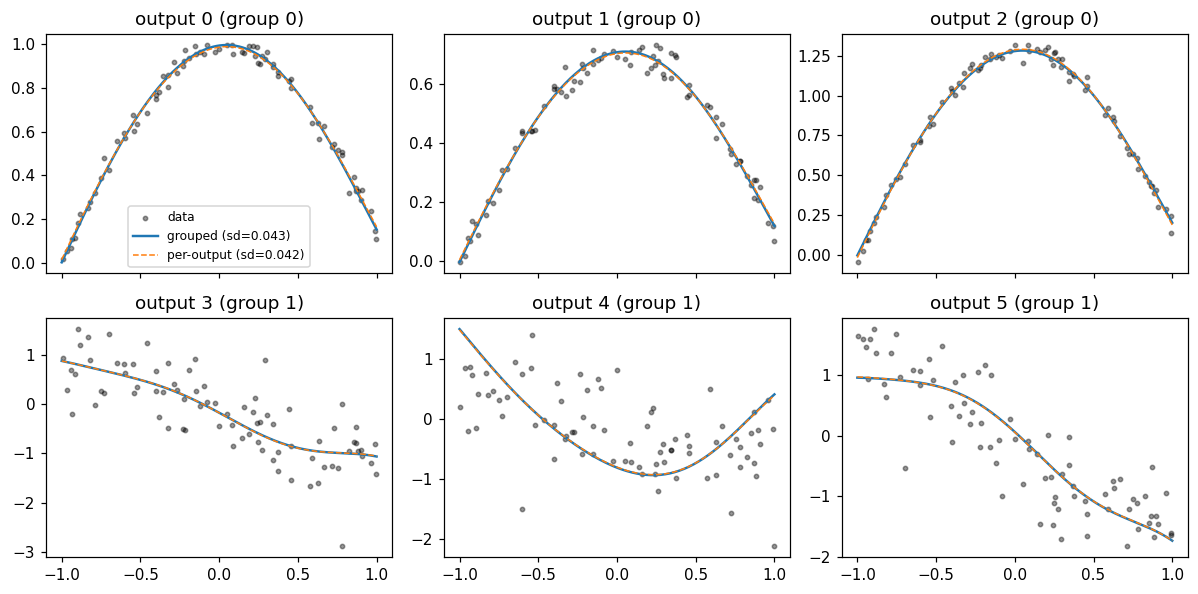

In [7]:
Xs = np.linspace(-1, 1, 200).reshape(-1, 1)
mean_grp, std_grp = model_grp.predict(Xs, return_std=True)
mean_full, std_full = model_full.predict(Xs, return_std=True)

fig, axes = plt.subplots(2, 3, figsize=(11, 5.5), sharex=True)
for j, ax in enumerate(axes.ravel()):
    ax.scatter(X.ravel(), Y[:, j], s=8, color='k', alpha=0.4, label='data')
    ax.plot(Xs.ravel(), mean_grp[:, j], color='C0', lw=1.6,
            label=f'grouped (sd={std_grp[:, j].mean():.3f})')
    ax.plot(Xs.ravel(), mean_full[:, j], color='C1', lw=1.0, ls='--',
            label=f'per-output (sd={std_full[:, j].mean():.3f})')
    grp = 0 if j < es[0] else 1
    ax.set_title(f'output {j} (group {grp})')
    if j == 0:
        ax.legend(loc='best', fontsize=8)
fig.tight_layout()

## 7. Validation behavior

`diag_error_structure` is checked when data is bound to the model. Mismatched
totals raise immediately.

In [8]:
# Direct helper inspection (used internally by the model and tests).
print('Default for p=4:', normalize_diag_error_structure(None, 4))
print('Valid grouping :', normalize_diag_error_structure([3, 2, 4], 9))

try:
    normalize_diag_error_structure([2, 2], 5)
except ValueError as e:
    print('Raised as expected:', e)

Default for p=4: (1, 1, 1, 1)
Valid grouping : (3, 2, 4)
Raised as expected: sum(diag_error_structure)=4 must equal p=5; got [2, 2]
